### SHAP Setup Probability

In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import shap

def collect_shap_data_lr_probability_kernel(
    data_path,
    target_column="Verletzungsstatus",
    cv_splits=5,
    cv_repeats=2,
    shap_background_size=100,   # kleiner halten für Tempo
    kernel_nsamples="auto",     # oder z.B. 100*X_test_s.shape[1]
    use_class_weight=False,
    max_iter=200,
    C=1.0,
    verbose=False
):
    # 1) Daten laden
    df = pd.read_excel(data_path)
    y  = df[target_column].astype(int)
    X  = df.drop(columns=[target_column])
    features = X.columns.tolist()

    # 2) CV
    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats, random_state=42)
    all_shap = []
    all_X    = []
    last_exp_val = None
    last_model   = None
    last_test_len = None

    rng = np.random.default_rng(42)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        if verbose: print(f"Fold {fold}")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # 3) Skalierung (keine Leaks)
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s  = scaler.transform(X_test)

        # 4) Logistische Regression
        lr = LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=max_iter,
            C=C,
            class_weight=("balanced" if use_class_weight else None)
        ).fit(X_train_s, y_train)

        last_model    = lr
        last_test_len = X_test_s.shape[0]

        # 5) KernelExplainer auf Probability
        classes = lr.classes_
        pos_idx = int(np.where(classes == 1)[0][0])

        f = lambda A: lr.predict_proba(A)[:, pos_idx]  # identity-link (Probability)

        n_bg = min(shap_background_size, len(X_train_s))
        bg_idx = rng.choice(len(X_train_s), size=n_bg, replace=False)
        bg = X_train_s[bg_idx, :]

        expl = shap.KernelExplainer(f, bg)
        # Achtung: alte API -> shap_values kann Liste sein
        phi = expl.shap_values(X_test_s, nsamples=kernel_nsamples)

        if isinstance(phi, list):
            vals = phi  # Liste pro Klasse
            vals = vals[pos_idx]  # Klasse 1
        else:
            vals = phi  # (n_test, p)

        # expected_value (Baseline-Probability)
        ev = expl.expected_value
        if isinstance(ev, (list, tuple, np.ndarray)):
            last_exp_val = float(np.ravel(ev)[pos_idx])
        else:
            last_exp_val = float(ev)

        # Sammeln
        all_shap.append(np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0))
        all_X.append(X_test_s)

    shap_stack = np.vstack(all_shap)      # ΔProbability
    X_stack    = np.vstack(all_X)

    signed_mean_shaps = np.nanmean(shap_stack, axis=0)
    abs_mean_shaps    = np.nanmean(np.abs(shap_stack), axis=0)

    return (features, shap_stack, X_stack, last_exp_val,
            last_model, last_test_len, signed_mean_shaps, abs_mean_shaps)

features, shap_stack, X_stack, exp_val, last_model, last_test_len, signed_mean_shaps, abs_mean_shaps = \
    collect_shap_data_lr_probability_kernel(
        r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\Motum_ML.xlsx",
        cv_splits=5, cv_repeats=20,
        shap_background_size=100,
        kernel_nsamples="auto",
        verbose=True
    )

print("exp_val (p):", exp_val)  # 0..1
print("min/max SHAP (p):", shap_stack.min(), shap_stack.max())
i = 0
print("p_base + sum(phi_i):", float(exp_val + shap_stack[i].sum()))


Fold 1


  0%|          | 0/14 [00:00<?, ?it/s]

Fold 2


  0%|          | 0/14 [00:00<?, ?it/s]

Fold 3


...

Fold 99


  0%|          | 0/13 [00:00<?, ?it/s]

Fold 100


  0%|          | 0/13 [00:00<?, ?it/s]

exp_val (p): 0.47269215734068815
min/max SHAP (p): -0.49343668859242584 0.487378290485387
p_base + sum(phi_i): 0.9645855832121595


In [2]:
print("exp_val =", exp_val)            # muss in [0, 1] liegen
print(shap_stack.min(), shap_stack.max())  # typische Beträge << 1 (z.B. ±0.1)
i = 0
print("p_base + sum(phi_i):", exp_val + shap_stack[i].sum())


exp_val = -0.10048865008408538
-4.601785791104535 4.450765755077146
p_base + sum(phi_i): 3.263142716914156


### SHAP Überprüfung

In [8]:
from scipy.special import expit
import numpy as np

# Indexbereich des letzten Folds im gestackten Array
start = len(X_stack) - last_test_len
end   = len(X_stack)

rng = np.random.default_rng(42)
idx_local = rng.choice(np.arange(start, end), size=min(5, last_test_len), replace=False)

p_from_shap   = []
p_from_model  = []

for i in idx_local:
    logit_i = exp_val + shap_stack[i].sum()        # log-odds rekonstruiert
    p_from_shap.append(expit(logit_i))             # -> Wahrscheinlichkeit
    p_from_model.append(last_model.predict_proba(X_stack[i].reshape(1, -1))[0, 1])

p_from_shap  = np.array(p_from_shap)
p_from_model = np.array(p_from_model)
diff = p_from_shap - p_from_model
print("\n=== SHAP Selbsttest (letzter Fold, Zufalls-Samples) ===")
print("Abweichung = P(rekonstruiert aus SHAP) – P(Modell)\n")
print(f"Maximale Abweichung : {np.max(np.abs(diff)):.3e}")
print(f"Mittlere Abweichung : {np.mean(np.abs(diff)):.3e}")
print(f"Median Abweichung   : {np.median(np.abs(diff)):.3e}\n")

for i in range(len(idx_local)):
    print(f"P_SHAP={p_from_shap[i]:.6f} | "
          f"P_Modell={p_from_model[i]:.6f} | "
          f"Δ={diff[i]:+.2e}")




=== SHAP Selbsttest (letzter Fold, Zufalls-Samples) ===
Abweichung = P(rekonstruiert aus SHAP) – P(Modell)

Maximale Abweichung : 4.893e-01
Mittlere Abweichung : 3.283e-01
Median Abweichung   : 3.760e-01

P_SHAP=0.541197 | P_Modell=0.165161 | Δ=+3.76e-01
P_SHAP=0.504632 | P_Modell=0.018530 | Δ=+4.86e-01
P_SHAP=0.676274 | P_Modell=0.736701 | Δ=-6.04e-02
P_SHAP=0.721316 | P_Modell=0.950998 | Δ=-2.30e-01
P_SHAP=0.503560 | P_Modell=0.014240 | Δ=+4.89e-01


### Motum: Beeswarm + Barplot (Probability)

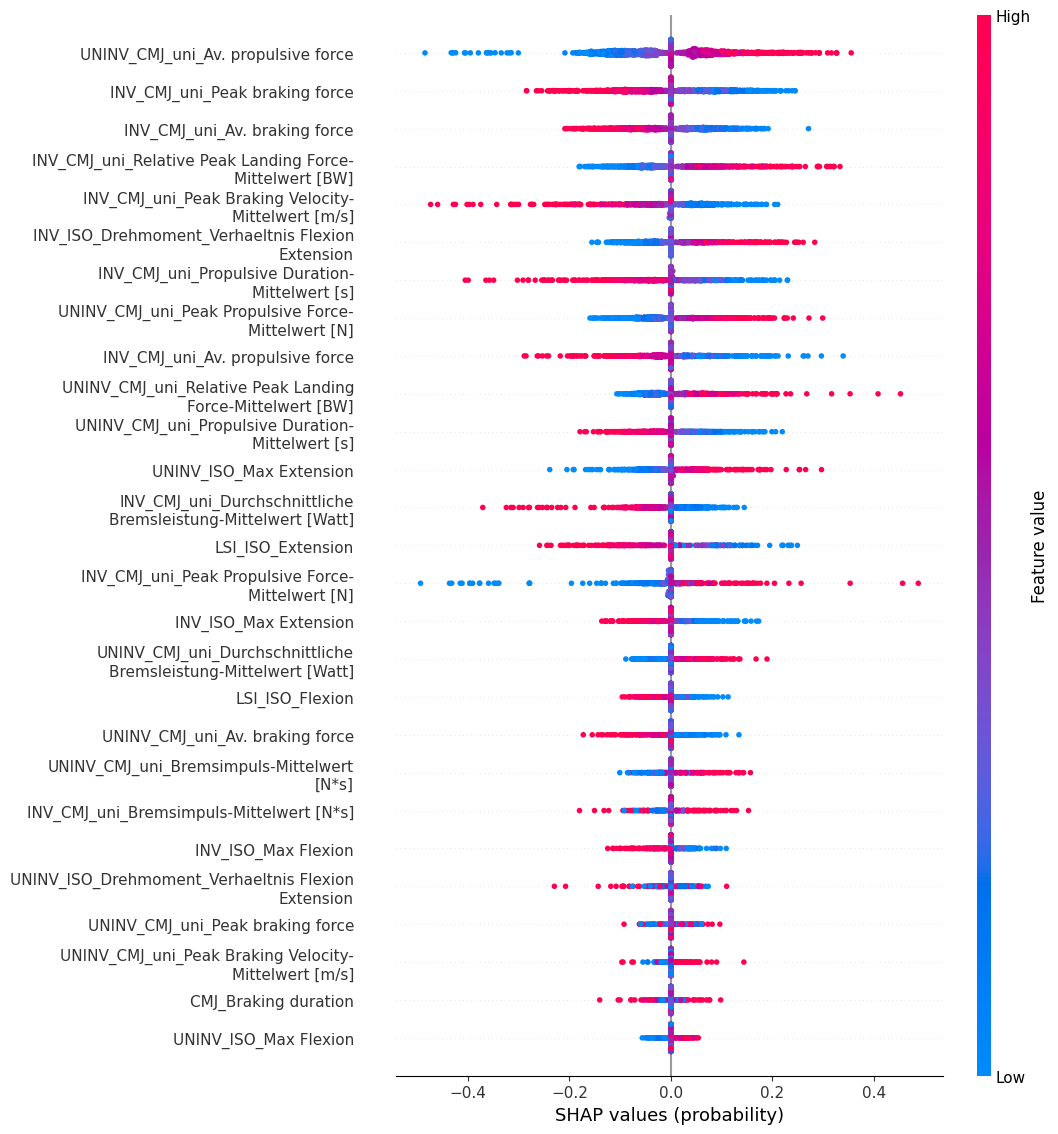

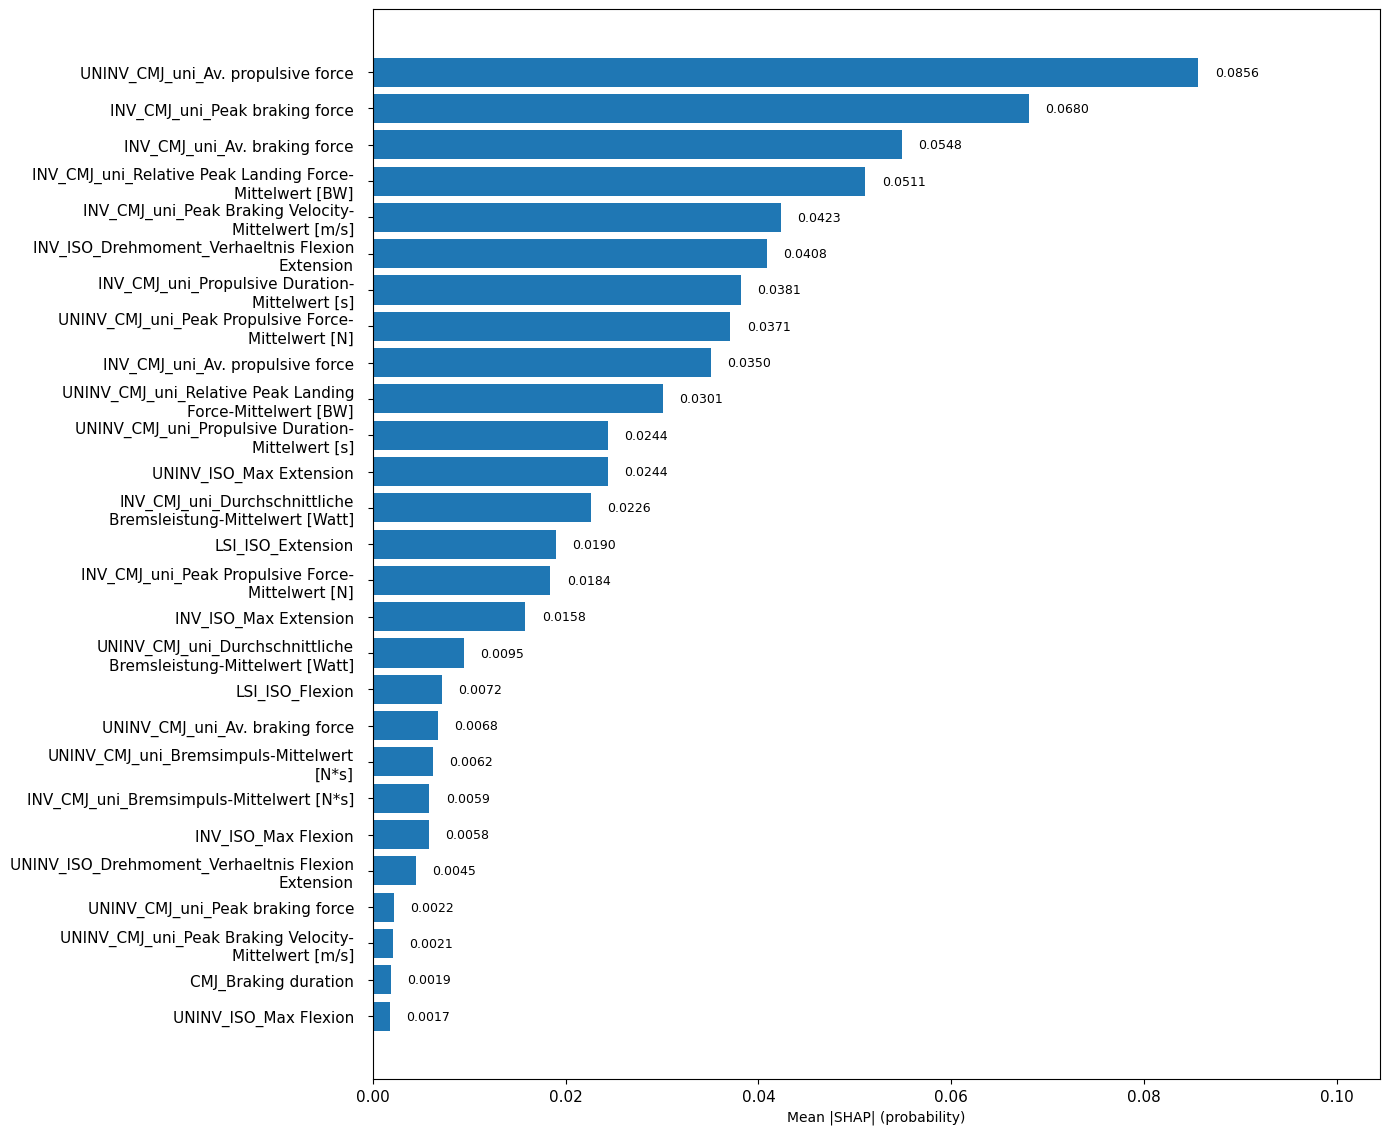

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import textwrap
import shap

# -----------------------------
# Parameter: Ranking-Auswahl
# -----------------------------
rank_by = "abs"   # "abs" oder "signed"
wrap_width = 40
row_height = 0.35
w = 11.0

# -----------------------------
# Reihenfolge basierend auf rank_by
# -----------------------------
if rank_by not in ("abs", "signed"):
    raise ValueError("rank_by must be 'abs' or 'signed'.")

if rank_by == "abs":
    ranking_scores = abs_mean_shaps.copy()                 # mean(|SHAP|) in Probability
else:  # rank_by == "signed"
    ranking_scores = np.abs(signed_mean_shaps).copy()      # |mean(SHAP)|

order_bar = np.argsort(ranking_scores)[::-1]               # absteigend (Top zuerst)
order_bee = order_bar                                      # gleiche Reihenfolge wie Balken

# Einheitliche Höhe pro Feature
h = row_height * len(order_bee) + 2.0

# Einheitliche, weich umgebrochene Labels in identischer Reihenfolge
wrapped_names = [textwrap.fill(features[i], width=wrap_width) for i in order_bee]

# =============================
# 1) BEESWARM (Probability)
# =============================
shap.summary_plot(
    shap_stack[:, order_bee],           # ΔProbability
    features=X_stack[:, order_bee],
    feature_names=wrapped_names,
    plot_type="dot",
    max_display=len(order_bee),
    sort=False,                         # wir liefern die Reihenfolge
    color_bar=True,
    plot_size=(w, h),
    show=False
)

ax = plt.gca()
ax.set_xlabel("SHAP values (probability)")
ax.tick_params(axis='y', labelsize=11, pad=10)
ax.tick_params(axis='x', labelsize=11)
plt.gcf().subplots_adjust(left=0.35, right=0.96, top=0.96, bottom=0.06)
plt.tight_layout()
plt.show()

# =============================
# 2) BALKENPLOT (zweite Grafik)
# =============================

w2 = 14.0        # Breite bei Bedarf weiter erhöhen
pad_frac = 0.22  # zusätzlicher Platz rechts/links für Labels

fig, ax = plt.subplots(figsize=(w2, h))
y = np.arange(len(order_bee))

if rank_by == "signed":
    # Anzeige: mean(SHAP) (Vorzeichen), Probability
    vals = signed_mean_shaps[order_bee]
    max_abs = np.nanmax(np.abs(vals)) if vals.size else 1.0
    ax.barh(y, vals)

    # Werte-Labels am Balkenende
    eps = 0.02 * max_abs
    for yi, v in zip(y, vals):
        if np.isfinite(v) and v != 0:
            ax.text(v + (eps if v > 0 else -eps), yi, f"{v:+.4f}",
                    va='center', ha=('left' if v > 0 else 'right'), fontsize=9)
        else:
            ax.text(0 + eps, yi, f"{0:+.4f}", va='center', ha='left', fontsize=9)

    # symmetrische Achse mit Extra-Puffer
    ax.set_xlim(-max_abs * (1 + pad_frac), max_abs * (1 + pad_frac))
    ax.axvline(0, linewidth=0.8)
    ax.set_xlabel("Mean SHAP (probability, signed)")

else:
    # Anzeige: mean(|SHAP|) (Probability)
    vals = abs_mean_shaps[order_bee]
    vmax = np.nanmax(vals) if vals.size else 1.0
    ax.barh(y, vals)

    eps = 0.02 * vmax
    for yi, v in zip(y, vals):
        v = 0.0 if not np.isfinite(v) else v
        ax.text(v + eps, yi, f"{v:.4f}", va='center', ha='left', fontsize=9)

    ax.set_xlim(0, vmax * (1 + pad_frac))
    ax.set_xlabel("Mean |SHAP| (probability)")

# Y-Achse und Layout wie im Beeswarm
ax.set_yticks(y)
ax.set_yticklabels(wrapped_names)
ax.invert_yaxis()  # damit das oberste Feature (Index 0) oben steht – konsistent zum Beeswarm
ax.tick_params(axis='y', labelsize=11, pad=10)
ax.tick_params(axis='x', labelsize=11)
fig.subplots_adjust(left=0.35, right=0.985, top=0.96, bottom=0.06)
plt.tight_layout()
plt.show()


### Lokaler Waterfall Plot (Probability)

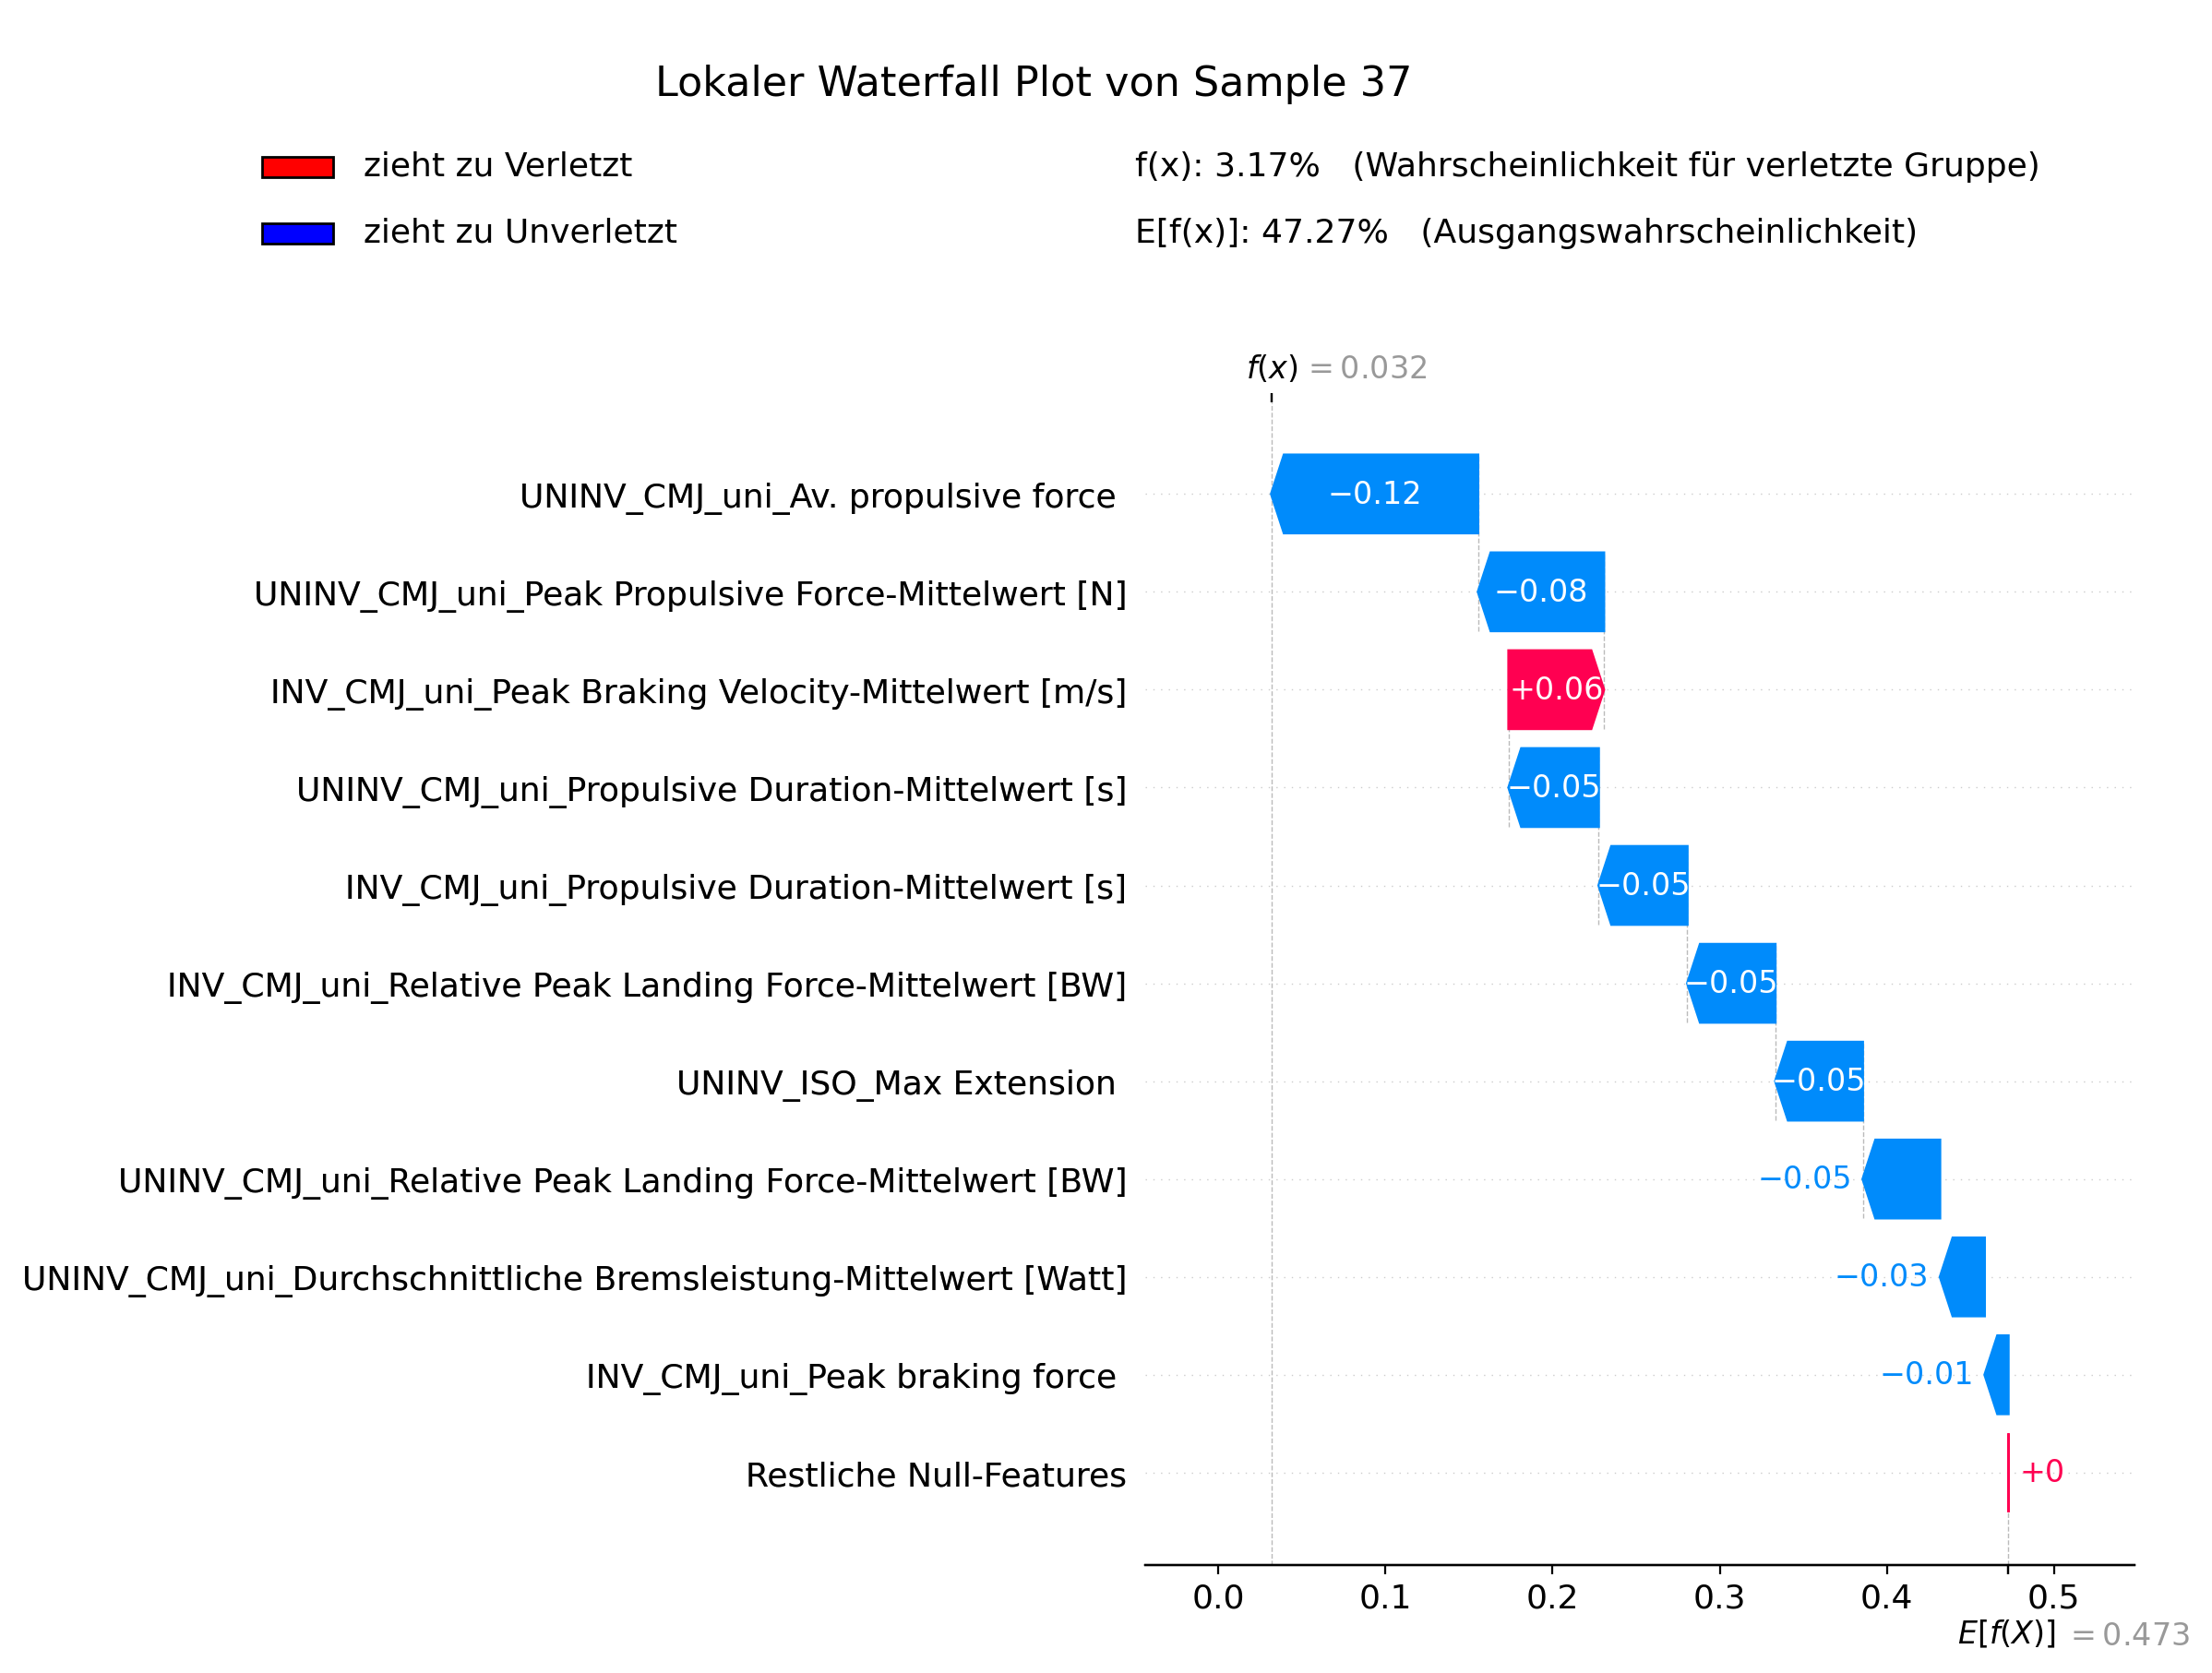

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from io import BytesIO
import tempfile, os
from PIL import Image
import shap

def _clamp01(x: float) -> float:
    return float(min(1.0, max(0.0, x)))

def plot_local_waterfall_combined_tempfiles(
    features,
    shap_stack,
    exp_val,              # Baseline-Probability (Klasse 1)
    sample_idx=None,
    combine_zeros=True,
    max_display=None,
    # Geometrie
    width=11.0, header_height=1.8, row_height=0.18, base_height=1.2,
    left=0.30, right=0.97, top=0.98, bottom=0.08,
    dpi=200,
    spacer_px=0
):
    # ----- Sample & Explanation vorbereiten -----
    if sample_idx is None:
        rng = np.random.default_rng(42)
        sample_idx = int(rng.integers(0, shap_stack.shape[0]))

    vals_full  = shap_stack[sample_idx, :]   # ΔProbability pro Feature
    names_full = list(features)

    if combine_zeros:
        nz = vals_full != 0
        vals  = vals_full[nz].tolist()
        names = [names_full[i] for i in range(len(names_full)) if nz[i]]
        if (~nz).sum() > 0:
            names.append("Restliche Null-Features"); vals.append(0.0)
    else:
        vals, names = vals_full.tolist(), names_full

    # SHAP Explanation in Probability-Einheiten
    exp = shap.Explanation(values=np.array(vals),
                           base_values=float(exp_val),   # Baseline p
                           feature_names=names)

    # --- Wahrscheinlichkeiten direkt additiv ---
    p_base = float(exp.base_values)
    p_fx   = float(exp.base_values + float(np.sum(exp.values)))
    # numerische Toleranzen vorsichtig auf [0,1] clampen
    p_base = _clamp01(p_base)
    p_fx   = _clamp01(p_fx)

    # ===== 1) Header-Plot -> temporäre PNG (ohne tight) =====
    figA = plt.figure(figsize=(width, header_height), dpi=dpi)
    axA = figA.add_axes([0, 0, 1, 1]); axA.axis("off")

    axA.text(0.5, 0.80, f"Lokaler Waterfall Plot von Sample {sample_idx}",
             ha="center", va="center", fontsize=16)

    x_left_patch, x_left_text, x_right_col = 0.12, 0.17, 0.55
    y1, y2 = 0.55, 0.35
    box_w, box_h = 0.035, 0.06

    axA.add_patch(Rectangle((x_left_patch, y1 - box_h/2), box_w, box_h,
                            facecolor="red", edgecolor="black", transform=axA.transAxes))
    axA.text(x_left_text, y1, "zieht zu Verletzt",
             ha="left", va="center", fontsize=13, transform=axA.transAxes)
    axA.text(x_right_col, y1,
             f"f(x): {p_fx:,.2%}   (Wahrscheinlichkeit für verletzte Gruppe)",
             ha="left", va="center", fontsize=13, transform=axA.transAxes)

    axA.add_patch(Rectangle((x_left_patch, y2 - box_h/2), box_w, box_h,
                            facecolor="blue", edgecolor="black", transform=axA.transAxes))
    axA.text(x_left_text, y2, "zieht zu Unverletzt",
             ha="left", va="center", fontsize=13, transform=axA.transAxes)
    axA.text(x_right_col, y2,
             f"E[f(x)]: {p_base:,.2%}   (Ausgangswahrscheinlichkeit)",
             ha="left", va="center", fontsize=13, transform=axA.transAxes)

    tmpA = tempfile.NamedTemporaryFile(delete=False, suffix=".png"); tmpA.close()
    figA.savefig(tmpA.name, format="png", dpi=dpi, facecolor=figA.get_facecolor(),
                 bbox_inches=None, pad_inches=0)
    plt.close(figA)

    # ===== 2) Waterfall-Plot -> temporäre PNG (ohne tight) =====
    n_rows = len(exp.values) if max_display is None else min(max_display, len(exp.values))
    heightB = base_height + row_height * n_rows

    figB = plt.figure(figsize=(width, heightB), dpi=dpi)
    shap.plots.waterfall(
        exp,
        show=False,
        max_display=(len(exp.values) if max_display is None else max_display)
    )
    # Ränder feinjustieren, damit Labels nicht abgeschnitten werden
    plt.gcf().subplots_adjust(left=left, right=right, top=top, bottom=bottom)

    tmpB = tempfile.NamedTemporaryFile(delete=False, suffix=".png"); tmpB.close()
    figB = plt.gcf()
    figB.canvas.draw()
    figB.savefig(tmpB.name, format="png", dpi=dpi, facecolor=figB.get_facecolor(),
                 bbox_inches="tight", pad_inches=0.02)
    plt.close(plt.gcf())

    # ===== 3) Beide PNGs laden & exakt untereinander packen =====
    imgA = Image.open(tmpA.name).convert("RGBA")
    imgB = Image.open(tmpB.name).convert("RGBA")

    # optionaler weißer Spacer
    spacer = None
    if spacer_px > 0:
        spacer = Image.new("RGBA", (max(imgA.width, imgB.width), spacer_px), (255, 255, 255, 255))

    # gleiche Breite herstellen durch weißes Padding (keine Skalierung)
    W = max(imgA.width, imgB.width)
    if imgA.width != W:
        pad = Image.new("RGBA", (W - imgA.width, imgA.height), (255, 255, 255, 255))
        imgA = Image.fromarray(np.hstack([np.array(imgA), np.array(pad)]))
    if imgB.width != W:
        pad = Image.new("RGBA", (W - imgB.width, imgB.height), (255, 255, 255, 255))
        imgB = Image.fromarray(np.hstack([np.array(imgB), np.array(pad)]))

    parts = [imgA]
    if spacer is not None: parts.append(spacer)
    parts.append(imgB)

    total_h = sum(p.height for p in parts)
    combo = Image.new("RGBA", (W, total_h), (255, 255, 255, 255))
    y = 0
    for p in parts:
        combo.paste(p, (0, y))
        y += p.height

    # ===== 4) Nur EIN Bild anzeigen =====
    combo_np = np.asarray(combo)[..., :3]  # RGB
    h_px, w_px = combo_np.shape[:2]
    fig = plt.figure(figsize=(w_px / dpi, h_px / dpi), dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1]); ax.axis("off")
    ax.imshow(combo_np, interpolation="none")
    plt.show()

    # Temp-Dateien aufräumen
    try:
        os.remove(tmpA.name); os.remove(tmpB.name)
    except Exception:
        pass

# --- Aufruf ---
plot_local_waterfall_combined_tempfiles(
    features=features,
    shap_stack=shap_stack,
    exp_val=exp_val,           # Baseline-Probability
    sample_idx=37,             # oder None
    combine_zeros=True,
    max_display=None,
    width=11.0, header_height=1.8, row_height=0.18, base_height=1.2,
    left=0.30, right=0.97, top=0.98, bottom=0.08,
    dpi=200, spacer_px=0
)
